In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Read and Merge Diabetes Datasets

Combine diabetes monitoring data with demographic and sleep information into a unified dataset:

1. Read the cleaned diabetes monitoring dataset and demographic dataset using pandas
2. Convert the TimeStamp column into datetime format for temporal analysis
3. Merge both datasets using Patient_ID as the common key
4.Preserve all diabetes monitoring records using a left join
5.Combine glucose, insulin, activity, sleep, and demographic features into one dataset
6. Save the merged dataset as a new CSV file for machine learning and analysis
7.Preview the merged dataset using data.head() to validate the integration process

In [2]:
df = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Cleaned_Diabetes_Data.csv")
demo = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\T1DM_patient_sleep_demographics_with_race.csv")

df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])

data = df.merge(demo, on="Patient_ID", how="left")

data.to_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Merged_Diabetes_Data.csv", index=False)

data.head()

,Patient_ID,TimeStamp,Date,Time,Hour,Minutes,Blood_Glucose_mg_dl,Basal_Insulin_Rate_Unit_hr,Bolus_Insulin_Dose_Units,Carbohydrate_Intake_Grams,Step_count,Calories_burned,Heart_Rate_bpm,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,2018-06-13 18:40:00,2018-06-13,18:40:00,18,40,332.0,0.09,0.0,0.0,34.0,6.36,82.32,34,Male,Other,6.3,4.5,80
1,HUPA0001P,2018-06-13 18:45:00,2018-06-13,18:45:00,18,45,326.0,0.09,0.0,0.0,0.0,7.73,83.74,34,Male,Other,6.3,4.5,80
2,HUPA0001P,2018-06-13 18:50:00,2018-06-13,18:50:00,18,50,330.0,0.09,0.0,0.0,0.0,4.75,80.53,34,Male,Other,6.3,4.5,80
3,HUPA0001P,2018-06-13 18:55:00,2018-06-13,18:55:00,18,55,324.0,0.09,0.0,0.0,20.0,6.36,89.13,34,Male,Other,6.3,4.5,80
4,HUPA0001P,2018-06-13 19:00:00,2018-06-13,19:00:00,19,0,306.0,0.08,0.0,0.0,0.0,5.15,92.50,34,Male,Other,6.3,4.5,80


### Create Hyperglycemia Risk Target Variable

1. Used blood glucose readings to identify hyperglycemia events
2. Classified glucose values greater than 180 mg/dL as hyperglycemia risk
3. Converted the condition into binary format:

   * `1` → Hyperglycemia Risk
   * `0` → Normal Glucose Range
4. Applied `.astype(int)` to convert Boolean values into machine learning compatible numeric labels
5. Created a target variable for supervised classification models
6. Used `value_counts(normalize=True)` to analyze class distribution and identify potential class imbalance in the dataset


In [3]:
data["Hyperglycemia_Risk"] = (
    data["Blood_Glucose_mg_dl"] > 180
).astype(int)

print(data["Hyperglycemia_Risk"].value_counts(normalize=True))

Hyperglycemia_Risk
0    0.783049
1    0.216951
Name: proportion, dtype: float64


### Feature Selection for Hyperglycemia Prediction Model

1. Selected time-based, physiological, insulin, activity, and demographic features relevant to glucose behavior
2. Included:

   * blood glucose measurements
   * insulin dosage
   * carbohydrate intake
   * physical activity
   * heart rate
   * patient age
3. Used `Hour` and `Minutes` to capture temporal glucose variation patterns
4. Stored selected input variables in `X` for machine learning training
5. Assigned `Hyperglycemia_Risk` as the target variable `y`
6. Prepared the dataset for supervised hyperglycemia risk classification models


In [6]:
features = [
    "Hour",
    "Minutes",
    "Blood_Glucose_mg_dl",
    "Basal_Insulin_Rate_Unit_hr",
    "Bolus_Insulin_Dose_Units",
    "Carbohydrate_Intake_Grams",
    "Step_count",
    "Calories_burned",
    "Heart_Rate_bpm",
    "Age"
]

X = data[features]

y = data["Hyperglycemia_Risk"]

# Train-Test Data Splitting for Hyperglycemia Prediction

1. Split the dataset into training and testing sets using `train_test_split()`
2. Used:

   * 80% data for model training
   * 20% data for model testing
3. Applied `random_state=42` to ensure reproducible and consistent results
4. Used `stratify=y` to preserve the original hyperglycemia class distribution in both datasets
5. Prepared separate datasets for unbiased machine learning model evaluation
6. Enabled reliable performance testing on unseen hyperglycemia prediction data


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model Training for Hyperglycemia Prediction

1. Initialized the Logistic Regression classification model for hyperglycemia risk prediction
2. Used `class_weight="balanced"` to handle class imbalance in hyperglycemia data
3. Set `max_iter=1000` to allow sufficient iterations for model convergence
4. Applied `random_state=42` to ensure reproducible model results
5. Trained the model using the prepared training dataset
6. Built a supervised classification model to predict hyperglycemia risk based on glucose, insulin, activity, and patient health features


In [8]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Generate Logistic Regression Predictions and Probability Scores for Hyperglycemia Prediction

1. Used the trained Logistic Regression model to predict hyperglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hyperglycemia risk class (`1`)
5. Used prediction probabilities for:

   * ROC Curve generation
   * ROC AUC evaluation
   * risk probability analysis
   * model performance assessment and comparison


In [9]:
lr_pred = lr_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Logistic Regression Model Performance Evaluation for Hyperglycemia Prediction

1. Evaluated the Logistic Regression model using multiple classification performance metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → correctness of predicted hyperglycemia cases
   * Recall → ability to detect actual hyperglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall classification and discrimination capability
3. Used both prediction labels and probability scores for comprehensive model evaluation
4. Assessed the effectiveness of the Logistic Regression model for hyperglycemia risk prediction and comparison with other machine learning models


In [10]:
print("===== Logistic Regression =====")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC AUC:", roc_auc_score(y_test, lr_prob))

===== Logistic Regression =====
Accuracy: 0.9998868759999353
Precision: 0.9999254843517139
Recall: 0.9995530726256984
F1 Score: 0.9997392438070404
ROC AUC: 0.9999995987670619


# Logistic Regression ROC Curve Visualization for Hyperglycemia Prediction

1. Generated the ROC Curve using Logistic Regression prediction probability scores
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s ability to distinguish between hyperglycemia and normal glucose conditions
4. Evaluated classification performance across multiple threshold values
5. Used the ROC Curve to assess the predictive capability of the Logistic Regression model
6. Supported comparison of Logistic Regression performance with other hyperglycemia prediction models


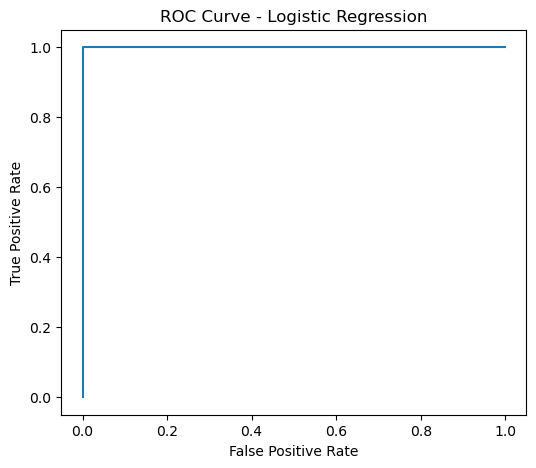

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

# Random Forest Model Training for Hyperglycemia Prediction

1. Initialized the Random Forest classification model for hyperglycemia risk prediction
2. Used `n_estimators=100` to build 100 decision trees for ensemble learning
3. Applied `class_weight="balanced"` to address class imbalance in hyperglycemia data
4. Used `random_state=42` to ensure reproducible model results
5. Trained the model using the prepared training dataset
6. Leveraged ensemble learning to capture complex and nonlinear glucose behavior patterns
7. Built a robust machine learning model for hyperglycemia risk classification


In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Generate Random Forest Predictions and Probability Scores for Hyperglycemia Prediction

1. Used the trained Random Forest model to predict hyperglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hyperglycemia risk class (`1`)
5. Used prediction probabilities for:

   * ROC Curve generation
   * ROC AUC evaluation
   * probability-based risk analysis
   * model performance comparison across classifiers


In [13]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

# Random Forest Model Performance Evaluation for Hyperglycemia Prediction

1. Evaluated the Random Forest model using multiple classification performance metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → correctness of predicted hyperglycemia cases
   * Recall → ability to detect actual hyperglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall classification and discrimination capability
3. Used prediction labels and probability scores for comprehensive model evaluation
4. Assessed the effectiveness of the Random Forest model for hyperglycemia risk prediction
5. Compared Random Forest performance with Logistic Regression and XGBoost models for healthcare risk classification


In [14]:
print("===== Random Forest =====")

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

===== Random Forest =====
Accuracy: 0.9999676788571243
Precision: 1.0
Recall: 0.9998510242085661
F1 Score: 0.9999255065554231
ROC AUC: 0.9999619851007299


# Random Forest ROC Curve Visualization for Hyperglycemia Prediction

1. Generated the ROC Curve using Random Forest prediction probability scores
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s ability to distinguish between hyperglycemia and normal glucose conditions
4. Evaluated classification performance across multiple threshold values
5. Used the ROC Curve to assess the predictive strength of the Random Forest model
6. Supported performance comparison with other hyperglycemia prediction models


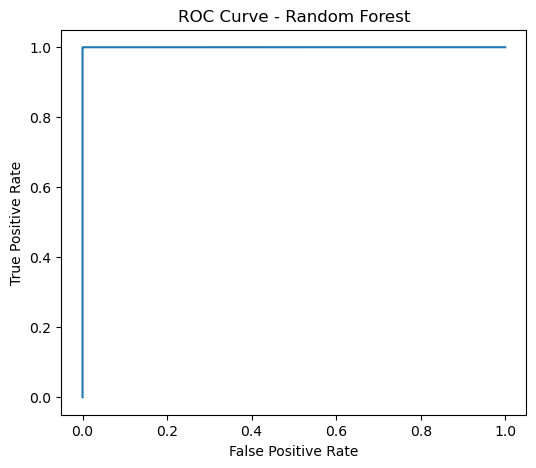

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.show()

# XGBoost Model Training for Hyperglycemia Prediction

1. Initialized the XGBoost classification model for hyperglycemia risk prediction
2. Used `n_estimators=100` to build multiple boosting trees for ensemble learning
3. Applied `learning_rate=0.1` to control the contribution of each tree during training
4. Set `max_depth=5` to limit tree complexity and reduce overfitting
5. Used `random_state=42` to ensure reproducible model results
6. Trained the model using the prepared training dataset
7. Leveraged gradient boosting to capture complex nonlinear relationships in glucose and patient health data
8. Built an advanced machine learning model for hyperglycemia risk classification


In [16]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Generate XGBoost Predictions and Probability Scores for Hyperglycemia Prediction

1. Used the trained XGBoost model to predict hyperglycemia risk on testing data
2. Generated class predictions using `predict()`
3. Generated probability scores using `predict_proba()`
4. Extracted probability values for the positive hyperglycemia risk class (`1`)
5. Used prediction probabilities for:

   * ROC Curve generation
   * ROC AUC evaluation
   * probability-based risk assessment
   * model performance comparison across machine learning classifiers


In [17]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# XGBoost Model Performance Evaluation for Hyperglycemia Prediction

1. Evaluated the XGBoost model using multiple classification performance metrics
2. Measured:

   * Accuracy → overall prediction correctness
   * Precision → correctness of predicted hyperglycemia cases
   * Recall → ability to detect actual hyperglycemia events
   * F1 Score → balance between precision and recall
   * ROC AUC → overall classification and discrimination capability
3. Used both prediction labels and probability scores for comprehensive model evaluation
4. Assessed the effectiveness of the XGBoost model for hyperglycemia risk prediction
5. Compared XGBoost performance with Logistic Regression and Random Forest models for healthcare risk classification


In [18]:
print("===== XGBoost =====")

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

===== XGBoost =====
Accuracy: 0.9990142051422938
Precision: 0.9968768590124926
Recall: 0.998584729981378
F1 Score: 0.9977300636326424
ROC AUC: 0.999994112944305


# XGBoost ROC Curve Visualization for Hyperglycemia Prediction

1. Generated the ROC Curve using XGBoost prediction probability scores
2. Calculated:

   * False Positive Rate (FPR)
   * True Positive Rate (TPR)
   * classification thresholds
3. Visualized the model’s ability to distinguish between hyperglycemia and normal glucose conditions
4. Evaluated classification performance across different threshold values
5. Used the ROC Curve to assess the predictive capability of the XGBoost model
6. Supported comparison of XGBoost performance with Logistic Regression and Random Forest models for hyperglycemia risk prediction


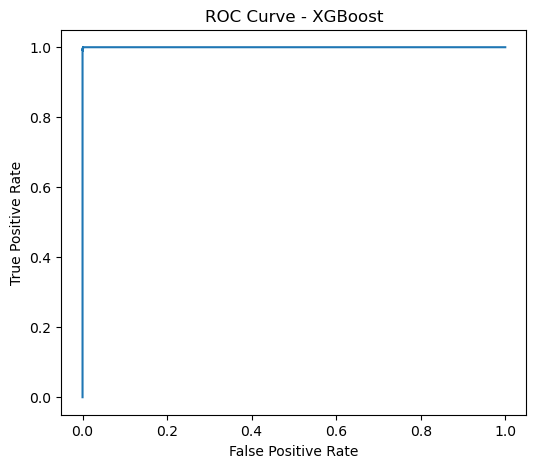

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.show()

# Hyperglycemia Model Comparison Summary

1. Created a comparison table using `pandas DataFrame`
2. Compared the performance of:

   * Logistic Regression
   * Random Forest
   * XGBoost
3. Evaluated each model using key classification metrics:

   * Accuracy
   * Precision
   * Recall
   * F1 Score
   * ROC AUC
4. Converted metric values into percentage format for easier interpretation and presentation
5. Rounded all metric values to 2 decimal places for better readability
6. Displayed the final comparison table to analyze and compare model performance for hyperglycemia risk prediction
7. Supported identification of the best-performing machine learning model based on evaluation metrics


In [21]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy (%)": [
        accuracy_score(y_test, lr_pred) * 100,
        accuracy_score(y_test, rf_pred) * 100,
        accuracy_score(y_test, xgb_pred) * 100
    ],

    "Precision (%)": [
        precision_score(y_test, lr_pred) * 100,
        precision_score(y_test, rf_pred) * 100,
        precision_score(y_test, xgb_pred) * 100
    ],

    "Recall (%)": [
        recall_score(y_test, lr_pred) * 100,
        recall_score(y_test, rf_pred) * 100,
        recall_score(y_test, xgb_pred) * 100
    ],

    "F1 Score (%)": [
        f1_score(y_test, lr_pred) * 100,
        f1_score(y_test, rf_pred) * 100,
        f1_score(y_test, xgb_pred) * 100
    ],

    "ROC AUC (%)": [
        roc_auc_score(y_test, lr_prob) * 100,
        roc_auc_score(y_test, rf_prob) * 100,
        roc_auc_score(y_test, xgb_prob) * 100
    ]
})

# Round to 2 decimal places
results = results.round(2)

display(results)

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC (%)
0,Logistic Regression,99.99,99.99,99.96,99.97,100.0
1,Random Forest,100.00,100.00,99.99,99.99,100.0
2,XGBoost,99.90,99.69,99.86,99.77,100.0


# Hyperglycemia Model Interpretation and Usage Summary

1. Added strengths for each machine learning model based on performance characteristics
2. Defined practical healthcare usage scenarios for:

   * Logistic Regression
   * Random Forest
   * XGBoost
3. Highlighted:

   * recall capability
   * nonlinear learning strength
   * overall predictive performance
4. Added real-world usage descriptions for healthcare monitoring and diabetes risk prediction
5. Displayed the enhanced comparison table for better model interpretation and presentation
6. Supported final model analysis and healthcare application understanding for hyperglycemia prediction


In [22]:
results["Strengths"] = [
    "High Recall",
    "Handles Nonlinear Data",
    "Best Overall Prediction"
]

results["Usage"] = [
    "Early Warning System",
    "General Risk Prediction",
    "Advanced Diabetes Monitoring"
]

display(results)

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC AUC (%),Strengths,Usage
0,Logistic Regression,99.99,99.99,99.96,99.97,100.0,High Recall,Early Warning System
1,Random Forest,100.00,100.00,99.99,99.99,100.0,Handles Nonlinear Data,General Risk Prediction
2,XGBoost,99.90,99.69,99.86,99.77,100.0,Best Overall Prediction,Advanced Diabetes Monitoring


# Best Hyperglycemia Model Selection

1. Identified the best-performing machine learning model using the highest ROC AUC score
2. Used `idxmax()` to locate the model with the maximum ROC AUC value
3. Selected the best model from the comparison results table
4. Displayed the best-performing model and its evaluation metrics
5. Supported final model selection for hyperglycemia risk prediction and healthcare monitoring applications
6. Used ROC AUC as the primary selection metric due to its effectiveness in evaluating classification performance across multiple thresholds


In [23]:
best_model = results.loc[
    results["ROC AUC (%)"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model             Logistic Regression
Accuracy (%)                    99.99
Precision (%)                   99.99
Recall (%)                      99.96
F1 Score (%)                    99.97
ROC AUC (%)                     100.0
Strengths                 High Recall
Usage            Early Warning System
Name: 0, dtype: object
